##README

**Overview**

This project implements an interpretable, rule-based nutrition scoring system that translates raw nutrient data into structured health scores.

**Motivation**

Inspired by the need for structured food intelligence systems, this project explores how nutrient-level signals can be transformed into consistent, explainable scoring logic.

**Methodology**

Designed weighted scoring system using protein, fiber, sugar, and sodium
Implemented threshold-based penalties for extreme values
Iteratively refined scoring logic based on edge cases
**Key Features**

Interpretable rule-based model
Handles tradeoffs between nutrients
Identifies edge cases (e.g., high protein but processed foods)

**Example Insights**

Whole foods (e.g., broccoli) score highly due to fiber + low sugar
Processed foods with high sodium are penalized
High-protein foods are not always “healthy” due to sodium tradeoffs

**Machine learning**

The hybrid model demonstrates how structured nutrition logic can be augmented by machine learning to capture nonlinear relationships while preserving interpretability. The rule-based system acts as a constraint layer, ensuring nutritional validity, while the ML model refines scoring based on learned patterns.

**Future Improvements**

Ingredient-level modeling,
Micronutrient integration

##Here we are designing a nutritional model

In [57]:
pip install pandas matplotlib seaborn requests

##Load Sample Food Data (simple dataset = fastest path)

In [58]:
import pandas as pd

data = [
    {"food": "Apple", "calories": 95, "protein": 0.5, "fiber": 4.4, "sugar": 19, "sodium": 2},
    {"food": "Chicken Breast", "calories": 165, "protein": 31, "fiber": 0, "sugar": 0, "sodium": 74},
    {"food": "Protein Bar", "calories": 220, "protein": 20, "fiber": 5, "sugar": 12, "sodium": 200},
    {"food": "Soda", "calories": 150, "protein": 0, "fiber": 0, "sugar": 39, "sodium": 45},
    {"food": "Broccoli", "calories": 55, "protein": 3.7, "fiber": 5.2, "sugar": 1.5, "sodium": 33},
    {"food": "Frozen Pizza", "calories": 300, "protein": 12, "fiber": 2, "sugar": 4, "sodium": 700},
]

df = pd.DataFrame(data)

##Build the Scoring Logic for nutritional facts

In [59]:
def nutrition_score(row):
    score = 0

    # Positive signals
    score += row["protein"] * 1.5
# Protein is a positive signal, but I cap its influence to prevent it from overpowering negative attributes like sodium or processing

    score += row["fiber"] * 2
# Fiber carries a higher weight because it’s both nutritionally beneficial and acts as a proxy for minimally processed foods, making it a strong anchor for the scoring system

    # Negative signals
    score -= row["sugar"] * 1.2
# Sugar is penalized as a negative signal, but its weight is moderated and paired with contextual adjustments to avoid over-penalizing whole foods like fruit

    score -= row["sodium"] / 100  # scaled
# Sodium is modeled using a scaled penalty to reflect its nonlinear health impact, with stronger penalties applied beyond threshold levels

    # Threshold penalties (edge-aware logic)
    if row["sugar"] > 25:
        score -= 10

    if row["sodium"] > 500:
        score -= 8

    # Bonus for whole-food-like profile
    if row["fiber"] > 3 and row["sugar"] < 10:
        score += 5

    return score

df["score"] = df.apply(nutrition_score, axis=1)

##Rank + Visualize

In [60]:
df = df.sort_values(by="score", ascending=False)

print(df[["food", "score"]])

             food  score
1  Chicken Breast  45.76
2     Protein Bar  23.60
4        Broccoli  18.82
5    Frozen Pizza   2.20
0           Apple -13.27
3            Soda -57.25


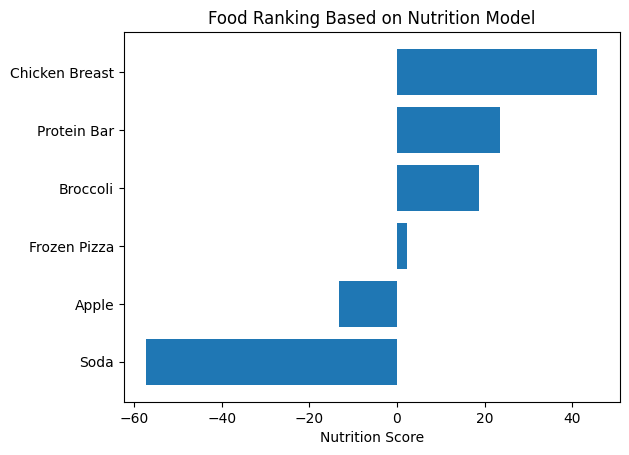

In [61]:
import matplotlib.pyplot as plt

plt.barh(df["food"], df["score"])
plt.xlabel("Nutrition Score")
plt.title("Food Ranking Based on Nutrition Model")
plt.gca().invert_yaxis()
plt.show()

The model is over-penalizing sugar without context. It treats intrinsic sugar in whole foods the same as added sugar in processed foods, which leads to unintuitive rankings like apples scoring poorly, this can be fixed by modifiying the whole food to fiber > 3 and sugar <25 or modifying how much sugar is penalized when there is a high fiber food

##Edge Case Analysis

In [62]:
   def nutrition_score(row):
    score = 0

    # Positive signals
    score += row["protein"] * 1.5
    score += row["fiber"] * 2

    # Negative signals
    score -= row["sugar"] * 1.2
    score -= row["sodium"] / 100  # scaled

    # Threshold penalties (edge-aware logic)
    if row["sugar"] > 25:
        score -= 10

    if row["sodium"] > 500:
        score -= 8

    # Bonus for whole-food-like profile
    if row["fiber"] > 3:
      score -= row["sugar"] * 0.5
    if row["fiber"] > 3 and row["sugar"] < 25:
        score += 25

    return score

df["score"] = df.apply(nutrition_score, axis=1)

In [63]:
df = df.sort_values(by="score", ascending=False)

print(df[["food", "score"]])

             food  score
1  Chicken Breast  45.76
2     Protein Bar  42.60
4        Broccoli  38.07
0           Apple   2.23
5    Frozen Pizza   2.20
3            Soda -57.25


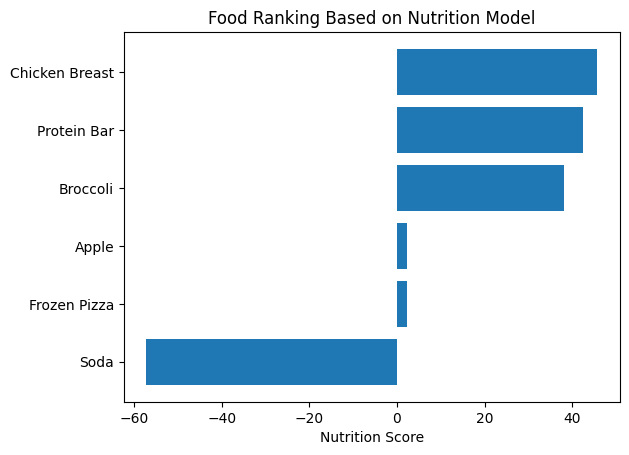

In [64]:
import matplotlib.pyplot as plt

plt.barh(df["food"], df["score"])
plt.xlabel("Nutrition Score")
plt.title("Food Ranking Based on Nutrition Model")
plt.gca().invert_yaxis()
plt.show()

In [65]:
print("\n--- Edge Case Analysis ---")

for _, row in df.iterrows():
    if row["protein"] > 15 and row["sodium"] > 400:
        print(f"High protein but high sodium: {row['food']}")

    if row["sugar"] > 30:
        print(f"Very high sugar: {row['food']}")


--- Edge Case Analysis ---
Very high sugar: Soda


## Machine learning, we create a proxy target health score

In [66]:
df["ml_target"] = (
    df["protein"] * 1.2 +
    df["fiber"] * 2 -
    df["sugar"] * 1.5 -
    df["sodium"] / 120
)

##Train a model

In [67]:
from sklearn.ensemble import RandomForestRegressor

features = ["calories", "protein", "fiber", "sugar", "sodium"]

X = df[features]
y = df["ml_target"]

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X, y)

df["ml_score"] = model.predict(X)

##Normalize scores

In [68]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df["rule_norm"] = normalize(df["score"])
df["ml_norm"] = normalize(df["ml_score"])

##Hybrid Score:
Rule system = ground truth logic

ML = pattern refinement layer

In [69]:
df["hybrid_score"] = 0.6 * df["rule_norm"] + 0.4 * df["ml_norm"]

##Compare Systems

In [70]:
print(df[["food", "score", "ml_score", "hybrid_score"]].sort_values(by="hybrid_score", ascending=False))

             food  score   ml_score  hybrid_score
1  Chicken Breast  45.76  27.213367      1.000000
2     Protein Bar  42.60  12.199700      0.892595
4        Broccoli  38.07   3.262767      0.813232
5    Frozen Pizza   2.20  10.107567      0.644876
0           Apple   2.23 -16.107900      0.489649
3            Soda -57.25 -40.264400      0.000000


##Visualization

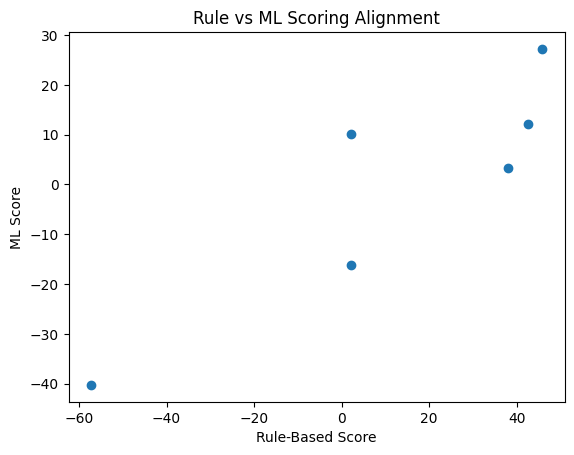

In [71]:
plt.scatter(df["score"], df["ml_score"])
plt.xlabel("Rule-Based Score")
plt.ylabel("ML Score")
plt.title("Rule vs ML Scoring Alignment")
plt.show()